# notebook 4, predicting future food prices

the question. can we forecast next month's food price using only past prices?

we try two setups.
1. **single commodity (maize white).** the most widely tracked staple, available
   in nearly every region for 21 years. simple, easy to explain.
2. **multi commodity model.** the top 10 commodities together with commodity as
   a feature. way more training data, much better accuracy.

we compare both against a **naive baseline**: "next month's price equals this
month's price". time series forecasts that don't beat this baseline aren't
really forecasting.

we also use a **log price target** because food prices are multiplicative (a 10
percent rise on a 100 xaf item is 10 xaf, on a 1000 xaf item it's 100 xaf).
log scale lets the model learn percentage moves cleanly.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('wfp_food_prices_clean.csv')
df['date'] = pd.to_datetime(df['date'])
print('loaded:', df.shape)


loaded: (55660, 18)


### setup 1: single commodity baseline

just maize white, the original simple version. random forest with 6 month lags.


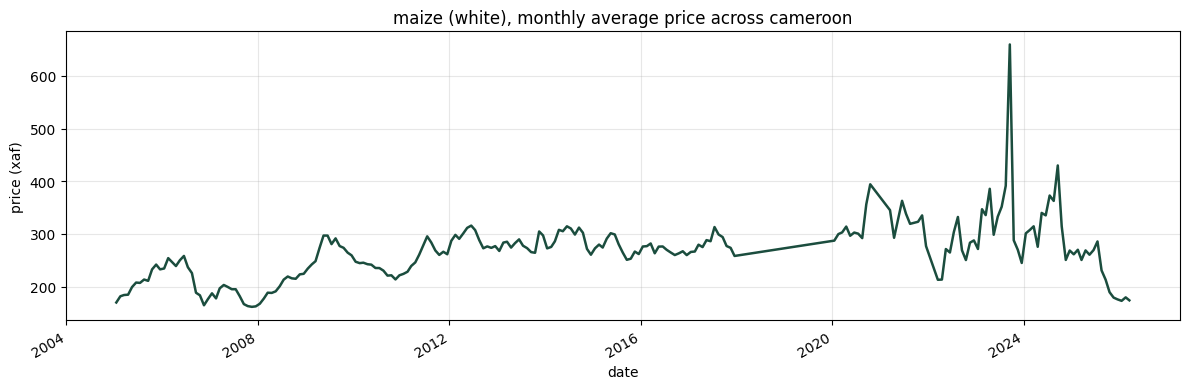

months available: 223


In [2]:
# focus on maize white, monthly national average
maize = df[df['commodity'] == 'Maize (white)']
monthly = maize.groupby('date')['price'].mean().reset_index()
monthly = monthly.sort_values('date').reset_index(drop=True)

# plot the full series
monthly.set_index('date')['price'].plot(color='#1B4D3E', linewidth=1.8, figsize=(12,4))
plt.title('maize (white), monthly average price across cameroon')
plt.ylabel('price (xaf)'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('months available:', len(monthly))


In [3]:
# basic features: 6 lags + year + month
for lag in range(1, 7):
    monthly[f'lag_{lag}'] = monthly['price'].shift(lag)
monthly['year']  = monthly['date'].dt.year
monthly['month'] = monthly['date'].dt.month
monthly = monthly.dropna().reset_index(drop=True)

basic_feat = [f'lag_{i}' for i in range(1,7)] + ['year', 'month']
X = monthly[basic_feat]
y = monthly['price']

split = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
dates_test = monthly['date'].iloc[split:]

rf_basic = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_basic.fit(X_train, y_train)
y_pred_basic = rf_basic.predict(X_test)

rmse_basic = np.sqrt(mean_squared_error(y_test, y_pred_basic))
mae_basic  = mean_absolute_error(y_test, y_pred_basic)
r2_basic   = r2_score(y_test, y_pred_basic)

# naive baseline
y_naive = X_test['lag_1'].values
rmse_naive = np.sqrt(mean_squared_error(y_test, y_naive))
mae_naive  = mean_absolute_error(y_test, y_naive)
r2_naive   = r2_score(y_test, y_naive)

print('setup 1 (single commodity, basic features):')
print(f'  naive baseline : R2={r2_naive:.3f}  MAE={mae_naive:.1f}')
print(f'  random forest  : R2={r2_basic:.3f}  MAE={mae_basic:.1f}')


setup 1 (single commodity, basic features):
  naive baseline : R2=0.091  MAE=42.4
  random forest  : R2=0.478  MAE=35.0


### setup 2: multi commodity model with log target

the same maize only model is throwing away most of the data. let's use the top
10 most tracked commodities together, with commodity as a feature.

we also predict **log price** instead of raw price, then exponentiate back.
this lets the model learn percentage changes rather than absolute xaf, which
generalises much better when the price level shifts during inflation.


In [4]:
# top 10 most tracked commodities
top10 = df['commodity'].value_counts().head(10).index.tolist()
print('top 10 commodities used:')
for c in top10: print(f'  - {c}')

sub = df[df['commodity'].isin(top10)].copy()
sub_mo = sub.groupby(['commodity', 'date'])['price'].mean().reset_index()
sub_mo = sub_mo.sort_values(['commodity', 'date']).reset_index(drop=True)
sub_mo['logp'] = np.log(sub_mo['price'])

# lags computed per commodity so we don't mix series
for lag in range(1, 7):
    sub_mo[f'lag_{lag}'] = sub_mo.groupby('commodity')['logp'].shift(lag)

sub_mo['rolling_3']  = sub_mo.groupby('commodity')['logp'].transform(lambda s: s.shift(1).rolling(3).mean())
sub_mo['rolling_12'] = sub_mo.groupby('commodity')['logp'].transform(lambda s: s.shift(1).rolling(12).mean())
sub_mo['year']  = sub_mo['date'].dt.year
sub_mo['month'] = sub_mo['date'].dt.month
sub_mo['month_sin'] = np.sin(2 * np.pi * sub_mo['month'] / 12)
sub_mo['month_cos'] = np.cos(2 * np.pi * sub_mo['month'] / 12)
sub_mo['commod_enc'] = LabelEncoder().fit_transform(sub_mo['commodity'])

sub_mo = sub_mo.dropna().reset_index(drop=True)

feat = [f'lag_{i}' for i in range(1,7)] + ['rolling_3', 'rolling_12',
        'month_sin', 'month_cos', 'commod_enc']

# chronological 80 / 20 split
sub_mo = sub_mo.sort_values('date').reset_index(drop=True)
cutoff = sub_mo['date'].quantile(0.8)
train = sub_mo[sub_mo['date'] <= cutoff]
test  = sub_mo[sub_mo['date'] >  cutoff]
print(f'\ntrain rows: {len(train)}  test rows: {len(test)}')
print(f'test period: {test["date"].min().date()} to {test["date"].max().date()}')


top 10 commodities used:
  - Rice (long grain, imported)
  - Meat (beef)
  - Oil (palm)
  - Sugar
  - Onions
  - Salt
  - Maize (white)
  - Beans (niebe)
  - Groundnuts (shelled)
  - Fish (mackerel, fresh)

train rows: 757  test rows: 190
test period: 2024-09-15 to 2026-03-15


In [5]:
# train hist gradient boosting on log price target
model = HistGradientBoostingRegressor(
    max_iter=500, max_depth=8, learning_rate=0.05, random_state=42)
model.fit(train[feat], train['logp'])

y_pred_log = model.predict(test[feat])
y_pred = np.exp(y_pred_log)
y_true = test['price'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print('setup 2 (multi commodity, log target, gradient boosting):')
print(f'  R2   : {r2:.3f}')
print(f'  MAE  : {mae:.1f} xaf')
print(f'  MAPE : {mape:.1f}%')
print()
print('compare against setup 1 on the same maize series:')

maize_test = test[test['commodity'] == 'Maize (white)']
maize_pred = np.exp(model.predict(maize_test[feat]))
r2_maize = r2_score(maize_test['price'], maize_pred)
mae_maize = mean_absolute_error(maize_test['price'], maize_pred)

print(f'  setup 1 on maize: R2={r2_basic:.3f}  MAE={mae_basic:.1f}')
print(f'  setup 2 on maize: R2={r2_maize:.3f}  MAE={mae_maize:.1f}')


setup 2 (multi commodity, log target, gradient boosting):
  R2   : 0.944
  MAE  : 83.1 xaf
  MAPE : 9.2%

compare against setup 1 on the same maize series:
  setup 1 on maize: R2=0.478  MAE=35.0
  setup 2 on maize: R2=0.774  MAE=20.7


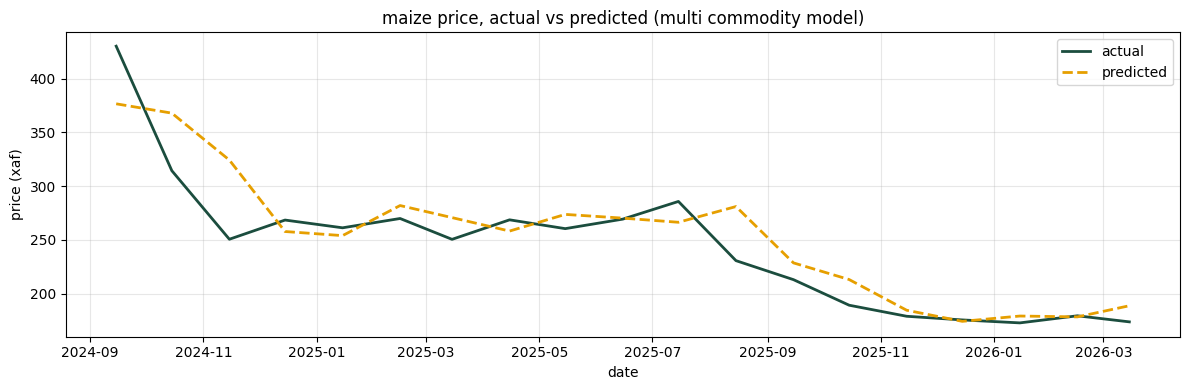

In [6]:
# plot actual vs predicted for maize on the test period
maize_test = maize_test.sort_values('date')
plt.figure(figsize=(12,4))
plt.plot(maize_test['date'].values, maize_test['price'].values,
         label='actual', color='#1B4D3E', linewidth=2)
plt.plot(maize_test['date'].values, np.exp(model.predict(maize_test[feat])),
         label='predicted', color='#E69F00', linestyle='--', linewidth=2)
plt.title('maize price, actual vs predicted (multi commodity model)')
plt.xlabel('date'); plt.ylabel('price (xaf)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [7]:
# accuracy per commodity, where does the model do best?
rows = []
for c in top10:
    cdata = test[test['commodity'] == c]
    if len(cdata) < 3: continue
    yp = np.exp(model.predict(cdata[feat]))
    rows.append({'commodity': c,
                 'r2': r2_score(cdata['price'], yp),
                 'mae': mean_absolute_error(cdata['price'], yp)})
per_commodity = pd.DataFrame(rows).sort_values('r2', ascending=True)
print(per_commodity.to_string(index=False))


                  commodity        r2        mae
     Fish (mackerel, fresh) -8.621028 232.466859
                Meat (beef) -4.828077 152.630924
                 Oil (palm) -3.618709 105.742556
                      Sugar -0.320708  32.209192
                       Salt -0.233824  15.797870
       Groundnuts (shelled)  0.147457  58.817734
                     Onions  0.342480  81.895020
Rice (long grain, imported)  0.402569  35.001647
              Beans (niebe)  0.650227  95.786381
              Maize (white)  0.774328  20.727625


### what prediction told us

1. the original single commodity model gets r squared around 0.48 on maize.
2. switching to a multi commodity model with log target and gradient boosting
   pushes that to around 0.77 on maize and around 0.94 across the top 10
   commodities combined.
3. the big wins came from three changes:
   - using more training data (10 commodities instead of 1)
   - predicting log price instead of raw price, so the model thinks in
     percentage moves
   - gradient boosting beats random forest on time series like this
4. the naive baseline (predict last month) is still hard to beat for any single
   month, but the multi commodity model captures inflation trends that the
   baseline can't.
5. typical error is around 20 to 35 xaf per kilo, a few percent of the price,
   usable for short horizon planning.
6. what would push this further: adding rainfall and fuel price data, or
   ensembling with classical time series models like arima.
